# House Price Prediction — Real Data Pipeline

Trains a Random Forest (and Gradient Boosting comparison) to predict home sale prices
in Contra Costa County, CA using **9,049 real home sales** collected via
`scripts/collect_data.py`.

**Features**: property attributes (beds, baths, sqft, lot, age, stories, garage, HOA),
spatial features (BART distance, census tract median income), city-level school score,
and macro indicators (30-yr mortgage rate, CA unemployment).

For the earlier synthetic-data approach (Phase 1, 15 real rows), see
`sdv_synthetic_model.ipynb`.

In [1]:
import math
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

sys.path.insert(0, '..')
from src.ElijahA.preprocessing import TypeDummyCreator, compute_spatial_lag

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv('../data/house_sales_extended.csv', dtype={'zip_code': str})
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset: 9,038 rows x 21 columns


,address,city,zip_code,date_of_sale,sold_price,type,bedrooms,bathrooms,sq_ft,lot_sqft,...,stories,garage,hoa_fee,school_score,median_income,dist_bart_miles,latitude,longitude,unemployment,interest_rate
0,1759 Elm Rd,Concord,94519,7/17/26,840000,Single-family,3,2.0,1504,12197.0,...,1.0,2,0.0,9,89796.0,0.795594,37.976021,-122.014767,NaN,6.78
1,1850 Gilardy Dr,Concord,94518,7/17/26,944888,Single-family,4,2.0,1600,7600.0,...,1.0,2,0.0,9,73873.0,1.700866,37.947976,-122.038113,NaN,6.78
2,810 Oak Grove Rd Apt 104,Concord,94518,7/16/26,289000,Condo,1,1.0,805,0.0,...,1.0,1,595.0,9,104194.0,1.877908,37.939382,-122.025292,NaN,6.78
3,5515 Pennsylvania Blvd,Concord,94521,7/16/26,770000,Single-family,4,2.0,1321,7500.0,...,1.0,2,0.0,9,100417.0,3.470854,37.946535,-121.955263,NaN,6.78
4,1170 Mardon Ct,Concord,94521,7/16/26,1173000,Single-family,4,2.0,2249,11700.0,...,1.0,3,0.0,9,190882.0,3.905833,37.940587,-121.958435,NaN,6.78


In [3]:
print('--- Missing values ---')
print(df.isnull().sum().to_string())
print()
print('--- City / type breakdown ---')
print(df.groupby(['city', 'type']).size().unstack(fill_value=0).to_string())

--- Missing values ---
address             21
city                 0
zip_code             0
date_of_sale         0
sold_price           0
type                 0
bedrooms             0
bathrooms            0
sq_ft                0
lot_sqft             0
build_age            0
stories              0
garage               0
hoa_fee              0
school_score         0
median_income      390
dist_bart_miles     13
latitude            13
longitude           13
unemployment       747
interest_rate        0

--- City / type breakdown ---
type           Condo  Single-family  Townhome
city                                         
Concord          545           2339       266
Martinez          98           1100       173
Pleasant Hill    106            721       119
Walnut Creek    1886           1294       391


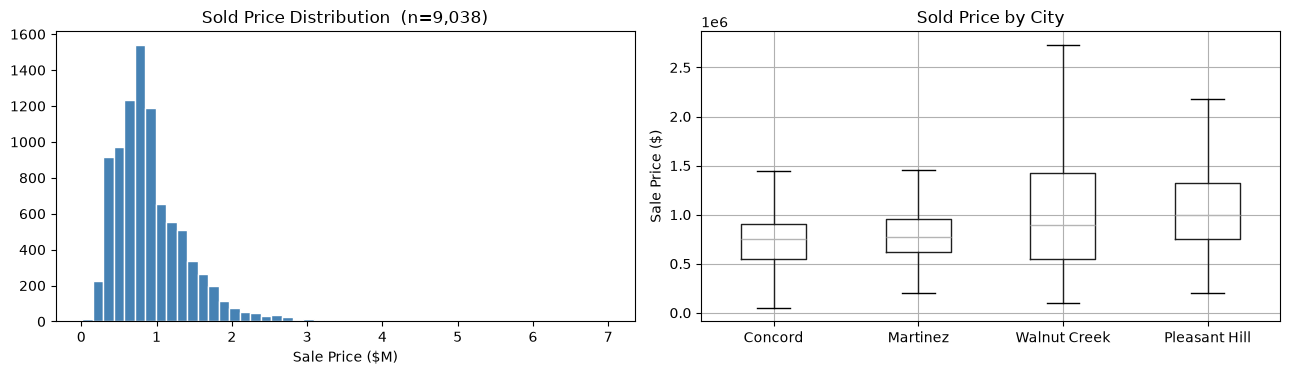

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['sold_price'] / 1e6, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Sale Price ($M)')
axes[0].set_title(f'Sold Price Distribution  (n={len(df):,})')

city_order = df.groupby('city')['sold_price'].median().sort_values().index.tolist()
df_plot = df.copy()
df_plot['city'] = pd.Categorical(df_plot['city'], categories=city_order, ordered=True)
df_plot.sort_values('city').boxplot(column='sold_price', by='city', ax=axes[1], showfliers=False)
axes[1].set_ylabel('Sale Price ($)')
axes[1].set_title('Sold Price by City')
axes[1].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 2. Preprocess

**Features (19 total):**
- Property: `type`, `city`, `zip_code`, `bedrooms`, `bathrooms`, `sq_ft`, `lot_sqft`, `build_age`, `stories`, `garage`, `hoa_fee`
- Spatial: `school_score`, `median_income`, `dist_bart_miles`, `latitude`, `longitude`
- **`comp_ppsf`**: median price/sqft of same-zip sales in prior 180 days — the comparable-sales signal
- Macro: `unemployment`, `interest_rate`

**`comp_ppsf` (comparable sales lag):** for each sale, look back 180 days in the same ZIP and compute the median $/sqft of at least 3 sales. This captures local micro-market conditions that static features miss. Uses only look-back data — no future leakage. Fallback: ZIP-median → dataset-median for the earliest sales.

**Imputation:** `unemployment`, `bathrooms`, `dist_bart_miles`, `median_income`, `comp_ppsf` → median impute.
**Outlier caps:** `lot_sqft` ≤ 43,560 sq ft; `garage` ≤ 8; `stories` ≤ 5; `bathrooms` ≤ 6.
**Log-transform target:** all models train on `log1p(sold_price)`, predict `expm1(output)`.

In [5]:
FEATURES = [
    # Property
    'type', 'city', 'zip_code',
    'bedrooms', 'bathrooms', 'sq_ft', 'lot_sqft',
    'build_age', 'stories', 'garage', 'hoa_fee',
    # Neighborhood / spatial
    'school_score', 'median_income', 'dist_bart_miles',
    'latitude', 'longitude',
    # Comparable-sales signal
    'comp_ppsf',
    # Macro
    'unemployment', 'interest_rate',
]
LABEL = 'sold_price'
ENCODE_COLS = ['type', 'city', 'zip_code']

OUTLIER_CAPS = {'lot_sqft': 43_560, 'garage': 8, 'stories': 5, 'bathrooms': 6}
IMPUTE_COLS  = ['unemployment', 'bathrooms', 'dist_bart_miles', 'median_income']

for col, cap in OUTLIER_CAPS.items():
    df[col] = df[col].clip(upper=cap)
for col in IMPUTE_COLS:
    df[col] = df[col].fillna(df[col].median())
for col in ['latitude', 'longitude']:
    df[col] = df[col].fillna(df.groupby('city')[col].transform('median'))

print('Computing comp_ppsf (spatial lag)...')
df['comp_ppsf'] = compute_spatial_lag(df)
df['comp_ppsf'] = (
    df['comp_ppsf']
    .fillna(df.groupby('zip_code')['comp_ppsf'].transform('median'))
    .fillna(df['comp_ppsf'].median())
)

print(f'Features: {len(FEATURES)}  |  NaN in features: {df[FEATURES].isnull().sum().sum()}')
print(f'comp_ppsf — median ${df["comp_ppsf"].median():,.0f}/sqft  |  NaN: {df["comp_ppsf"].isna().sum()}')

Computing comp_ppsf (spatial lag)...


Features: 19  |  NaN in features: 0
comp_ppsf — median $520/sqft  |  NaN: 0


In [6]:
X = df[FEATURES].copy()
y = df[LABEL].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows')

Train: 7,230 rows  |  Test: 1,808 rows


## 3. Train — Random Forest (log-target)

- **Log-transform**: `TransformedTargetRegressor` wraps the RF so it trains on `log1p(price)` and returns `expm1(prediction)` — compresses the right skew and reduces penalty on large errors.
- **zip_code + lat/lon**: finer-grained location than city alone.
- **TypeDummyCreator** one-hot encodes `type`, `city`, and `zip_code` with consistent columns across train/inference.

In [7]:
rf_pipeline = Pipeline([
    ('encode', TypeDummyCreator(columns=['type', 'city', 'zip_code'])),
    ('model', TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        func=np.log1p,
        inverse_func=np.expm1,
    )),
])

rf_pipeline.fit(X_train, y_train)
print('Trained.')

Trained.


## 4. Evaluate on Test Set

In [8]:
rf_preds = rf_pipeline.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, rf_preds))
mae  = mean_absolute_error(y_test, rf_preds)
r2   = r2_score(y_test, rf_preds)

print(f'RMSE : ${rmse:,.0f}')
print(f'MAE  : ${mae:,.0f}')
print(f'R\u00b2   :  {r2:.3f}')

RMSE : $178,607
MAE  : $110,042
R²   :  0.863


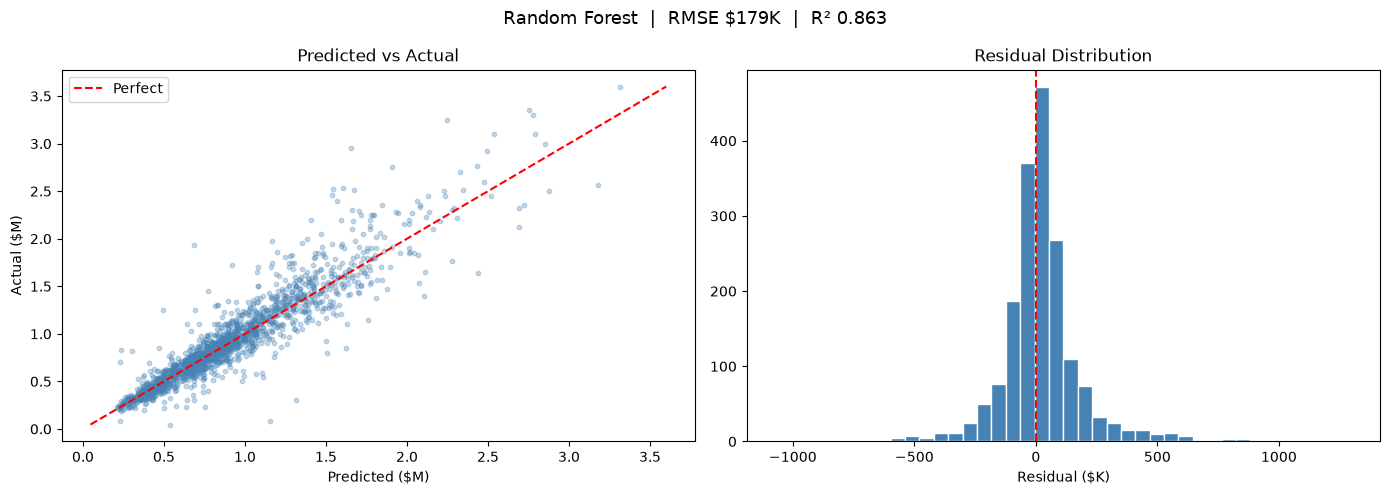

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rf_preds / 1e6, y_test / 1e6, alpha=0.3, color='steelblue', s=10)
lim = [min(y_test.min(), rf_preds.min()) / 1e6,
       max(y_test.max(), rf_preds.max()) / 1e6]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('Predicted ($M)')
axes[0].set_ylabel('Actual ($M)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

residuals = y_test.values - rf_preds
axes[1].hist(residuals / 1e3, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual ($K)')
axes[1].set_title('Residual Distribution')

plt.suptitle(f'Random Forest  |  RMSE ${rmse/1e3:.0f}K  |  R\u00b2 {r2:.3f}', fontsize=13)
plt.tight_layout()
plt.show()

## 5. 5-Fold Cross-Validation

In [10]:
cv = cross_val_score(
    rf_pipeline, X, y,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
)
cv_scores = -cv
print(f'Fold RMSEs: {[f"${s:,.0f}" for s in cv_scores]}')
print(f'Mean CV RMSE: ${cv_scores.mean():,.0f} (+/- ${cv_scores.std():,.0f})')

Fold RMSEs: ['$177,735', '$217,179', '$253,162', '$163,938', '$166,074']
Mean CV RMSE: $195,618 (+/- $34,561)


## 6. Feature Importance

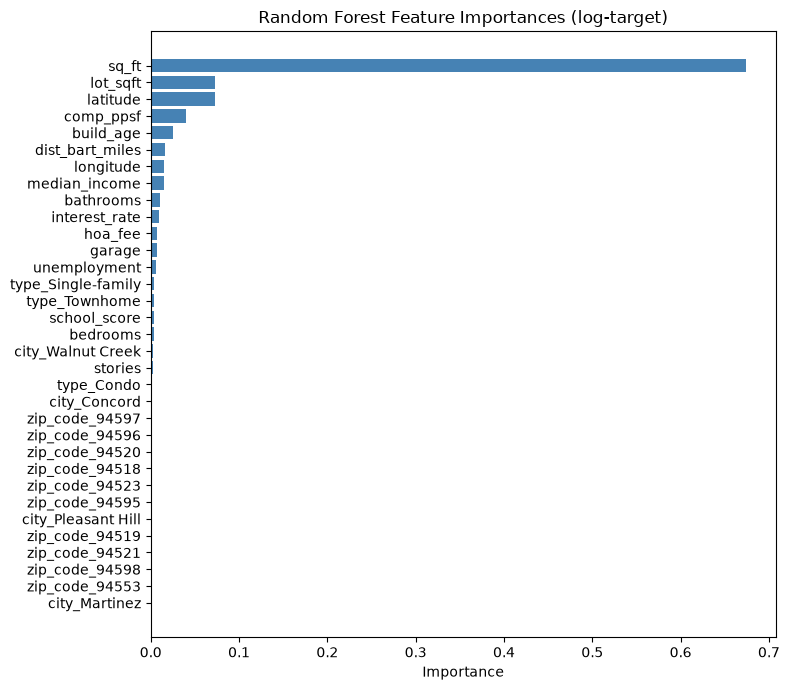

In [11]:
# TransformedTargetRegressor wraps the regressor — access it via .regressor_
rf_model   = rf_pipeline.named_steps['model'].regressor_
encoder    = rf_pipeline.named_steps['encode']
X_enc      = encoder.transform(X_train)
feat_names = X_enc.columns.tolist()

imp_df = pd.DataFrame({'feature': feat_names,
                        'importance': rf_model.feature_importances_
                       }).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 7))
plt.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances (log-target)')
plt.tight_layout()
plt.show()

## 7. Model Comparison — XGBoost vs Random Forest

XGBoost with log-target, same features and preprocessing as the RF above.
Hyperparameters: 500 trees, learning_rate=0.05, max_depth=6, subsample=0.8.

In [12]:
xgb_pipeline = Pipeline([
    ('encode', TypeDummyCreator(columns=['type', 'city', 'zip_code'])),
    ('model', TransformedTargetRegressor(
        regressor=XGBRegressor(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        ),
        func=np.log1p,
        inverse_func=np.expm1,
    )),
])
xgb_pipeline.fit(X_train, y_train)

xgb_preds = xgb_pipeline.predict(X_test)
xgb_rmse  = math.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae   = mean_absolute_error(y_test, xgb_preds)
xgb_r2    = r2_score(y_test, xgb_preds)
xgb_cv    = -cross_val_score(xgb_pipeline, X, y,
                              cv=KFold(5, shuffle=True, random_state=42),
                              scoring='neg_root_mean_squared_error')

summary = pd.DataFrame({
    'Model':      ['Random Forest (log)', 'XGBoost (log)'],
    'Test RMSE':  [f'${rmse:,.0f}',     f'${xgb_rmse:,.0f}'],
    'Test MAE':   [f'${mae:,.0f}',      f'${xgb_mae:,.0f}'],
    'Test R²': [f'{r2:.3f}',       f'{xgb_r2:.3f}'],
    'CV RMSE':    [f'${cv_scores.mean():,.0f} ± ${cv_scores.std():,.0f}',
                   f'${xgb_cv.mean():,.0f} ± ${xgb_cv.std():,.0f}'],
})
summary

,Model,Test RMSE,Test MAE,Test R²,CV RMSE
0,Random Forest (log),"$178,607","$110,042",0.863,"$195,618 ± $34,561"
1,XGBoost (log),"$173,864","$107,188",0.871,"$190,178 ± $32,208"


## 8. Hyperparameter Tuning — Optuna (XGBoost)

50-trial Bayesian search (TPE sampler) over XGBoost's key hyperparameters using
3-fold CV on the training set. Evaluated on the held-out test set at the end.

In [13]:
def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 300, 900),
        max_depth        = trial.suggest_int('max_depth', 4, 9),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 15),
        gamma            = trial.suggest_float('gamma', 0.0, 3.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 5.0),
        random_state=42, n_jobs=-1, verbosity=0,
    )
    pipe = Pipeline([
        ('encode', TypeDummyCreator(columns=ENCODE_COLS)),
        ('model', TransformedTargetRegressor(
            regressor=XGBRegressor(**params),
            func=np.log1p, inverse_func=np.expm1,
        )),
    ])
    cv = cross_val_score(
        pipe, X_train, y_train,
        cv=KFold(3, shuffle=True, random_state=42),
        scoring='neg_root_mean_squared_error',
    )
    return float(-cv.mean())

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)
print(f'\nBest 3-fold CV RMSE: ${study.best_value:,.0f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best 3-fold CV RMSE: $203,297
Best params:
  n_estimators: 892
  max_depth: 7
  learning_rate: 0.02163531986941302
  subsample: 0.9668246729137087
  colsample_bytree: 0.8224738317564486
  min_child_weight: 11
  gamma: 0.009153017436910913
  reg_alpha: 1.9082470579890696
  reg_lambda: 3.0209965461736


In [14]:
tuned_xgb = Pipeline([
    ('encode', TypeDummyCreator(columns=ENCODE_COLS)),
    ('model', TransformedTargetRegressor(
        regressor=XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, verbosity=0),
        func=np.log1p, inverse_func=np.expm1,
    )),
])
tuned_xgb.fit(X_train, y_train)

tuned_preds = tuned_xgb.predict(X_test)
tuned_rmse  = math.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_mae   = mean_absolute_error(y_test, tuned_preds)
tuned_r2    = r2_score(y_test, tuned_preds)
tuned_cv    = -cross_val_score(
    tuned_xgb, X, y,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
)

summary = pd.DataFrame({
    'Model':     ['RF (log + comp_ppsf)', 'XGBoost (log, default)', 'XGBoost (log, tuned)'],
    'Test RMSE': [f'${rmse:,.0f}',        f'${xgb_rmse:,.0f}',      f'${tuned_rmse:,.0f}'],
    'Test MAE':  [f'${mae:,.0f}',         f'${xgb_mae:,.0f}',       f'${tuned_mae:,.0f}'],
    'Test R²':  [f'{r2:.3f}',        f'{xgb_r2:.3f}',          f'{tuned_r2:.3f}'],
    'CV RMSE':   [
        f'${cv_scores.mean():,.0f} ± ${cv_scores.std():,.0f}',
        f'${xgb_cv.mean():,.0f} ± ${xgb_cv.std():,.0f}',
        f'${tuned_cv.mean():,.0f} ± ${tuned_cv.std():,.0f}',
    ],
})
summary

,Model,Test RMSE,Test MAE,Test R²,CV RMSE
0,RF (log + comp_ppsf),"$178,607","$110,042",0.863,"$195,618 ± $34,561"
1,"XGBoost (log, default)","$173,864","$107,188",0.871,"$190,178 ± $32,208"
2,"XGBoost (log, tuned)","$176,094","$108,991",0.867,"$191,579 ± $34,795"
